In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial import cKDTree

In [18]:
# Load dataset
df = pd.read_csv("size_trials3.csv", header=None)
print(df.shape)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply PCA over all components to find contribution
pca = PCA(n_components=56)
pca.fit(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Print contribution of each principal component
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f} ({ratio*100:.2f}% of total variance)")

(892, 56)
Principal Component 1: 0.5074 (50.74% of total variance)
Principal Component 2: 0.0699 (6.99% of total variance)
Principal Component 3: 0.0271 (2.71% of total variance)
Principal Component 4: 0.0235 (2.35% of total variance)
Principal Component 5: 0.0193 (1.93% of total variance)
Principal Component 6: 0.0187 (1.87% of total variance)
Principal Component 7: 0.0171 (1.71% of total variance)
Principal Component 8: 0.0159 (1.59% of total variance)
Principal Component 9: 0.0154 (1.54% of total variance)
Principal Component 10: 0.0138 (1.38% of total variance)
Principal Component 11: 0.0123 (1.23% of total variance)
Principal Component 12: 0.0111 (1.11% of total variance)
Principal Component 13: 0.0108 (1.08% of total variance)
Principal Component 14: 0.0105 (1.05% of total variance)
Principal Component 15: 0.0103 (1.03% of total variance)
Principal Component 16: 0.0091 (0.91% of total variance)
Principal Component 17: 0.0087 (0.87% of total variance)
Principal Component 18: 0.008

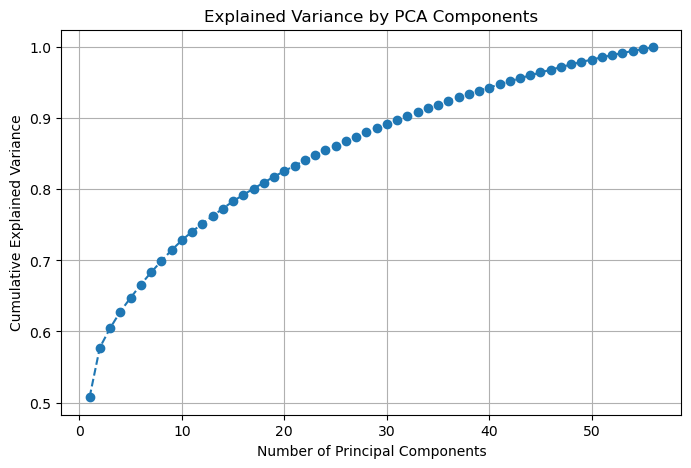

In [19]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 57), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

In [20]:
# Reduce dimensions to 3D using PCA - accounts for > 60% of variance
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

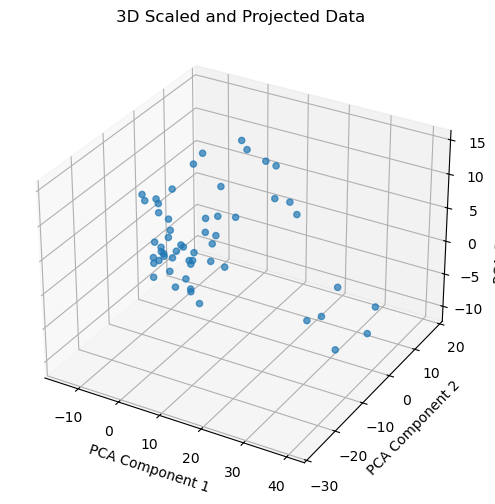

In [15]:
# 3D Plot of data points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.7)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D Scaled and Projected Data")

plt.show()

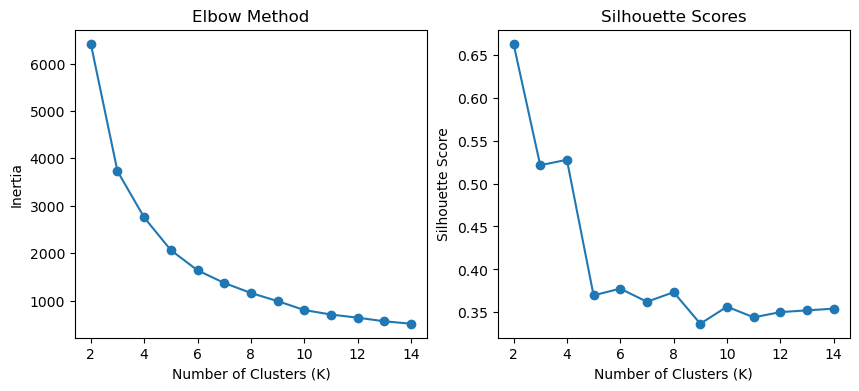

In [16]:
# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

In [8]:
# Choose the best K based on Elbow or Silhouette
optimal_k = 5  # Replace with your chosen K

# Fit K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Analyze cluster distribution
print(df['Cluster'].value_counts())

# Add cluster labels back to the original dataset
df.to_csv("clustered_data.csv", index=False)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
print("Cluster labels:", labels.shape)
print("Centroids shape:", centroids.shape)
print(labels)
print(centroids)

Cluster
2    498
0    243
1     86
3     38
4     27
Name: count, dtype: int64
Cluster labels: (892,)
Centroids shape: (5, 3)
[2 0 2 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 0 2 0 2 2 2 2 2 2 0 1 2 1 2 2 3 2 0 2
 2 1 2 2 2 0 2 2 2 2 2 2 2 0 0 2 2 2 3 2 2 2 2 3 2 2 2 2 2 2 2 2 2 0 2 2 0
 2 2 2 2 2 2 0 2 2 2 2 0 0 0 2 2 2 2 2 2 4 2 2 0 2 2 0 2 2 1 2 2 2 2 0 0 4
 2 2 0 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 0 2 2 0 2 2 2 0 2 1 0 1 1 2 2 3 2 2
 2 2 2 2 2 0 3 0 2 2 2 0 2 2 2 2 2 4 4 0 2 2 2 2 2 2 2 2 1 2 0 2 0 3 2 2 2
 2 1 2 2 0 2 2 2 2 0 2 2 0 2 2 2 2 2 2 2 2 2 0 2 0 2 2 2 4 2 2 2 2 0 2 2 2
 2 2 2 2 2 4 2 2 2 2 1 0 2 2 2 2 0 2 2 1 2 2 2 0 0 2 2 2 2 0 1 0 0 2 2 2 2
 4 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 4 2 2 0 3 2 2 0 2 2 2 2 0 0 2 3 2 0 0 0 3
 2 2 2 2 2 2 2 2 2 2 2 0 2 2 0 0 0 2 0 2 2 2 2 2 2 0 2 2 2 2 2 2 0 0 2 1 2
 2 1 1 2 4 2 1 2 0 4 0 1 1 1 2 2 2 0 2 0 1 2 2 2 4 0 0 0 2 4 2 2 0 2 0 4 3
 3 3 0 1 0 4 2 1 2 0 2 2 2 2 2 2 2 2 2 0 4 2 1 1 0 2 2 2 2 2 2 2 2 2 2 2 0
 0 0 0 0 0 3 0 0 2 2 0 0 2 2 2 2 4 2 2 2 0 0 2 2 

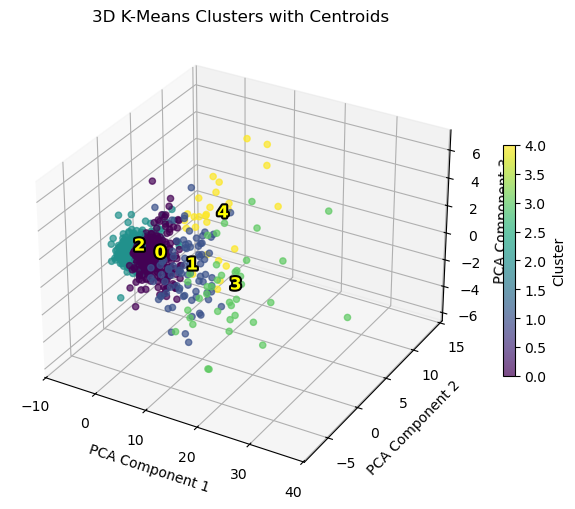

In [9]:
# 3D Plot of clusters with centroids
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Cluster'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Overlay centroids (bigger, red, distinct marker)
# ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='black', marker='X', s=200, edgecolors='black', label='Centroids', zorder=2)

# Add labels to the centroids with slight offsets to avoid overlap
# offsets = np.random.normal(0, 0.01, size=(optimal_k, 3))  # Small random offsets for spacing
for i in range(optimal_k):
    text = ax.text(centroids[i, 0], # + offsets[i, 0], 
            centroids[i, 1],        #  + offsets[i, 1], 
            centroids[i, 2],        #  + offsets[i, 2], 
            f'{i}', color='yellow', fontsize=12, weight='bold', zorder=3)

    # Add halo effect (black outline)
    text.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), 
                            path_effects.Normal()])
    
# Labels and titled
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D K-Means Clusters with Centroids")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()

In [17]:
# Reduce dimensions to 2D using PCA - still accounts for nearly 60% of variance
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

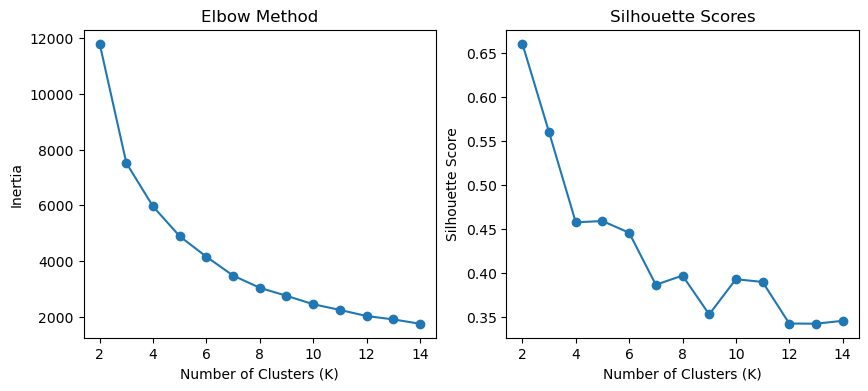

In [18]:
# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

In [19]:
# Choose the best K based on Elbow or Silhouette
optimal_k = 5  # Replace with your chosen K

# Fit K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Analyze cluster distribution
print(df['Cluster'].value_counts())

# Add cluster labels back to the original dataset
df.to_csv("clustered_data.csv", index=False)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Merge clusters in with coordinate
cluster = df.iloc[:, 56].values.reshape(-1, 1)  # Select the cluster column (0-indexed, so it's column 56)
ms = np.hstack((X_pca, cluster))  # Combine X_pca and the cluster

Cluster
2    498
0    244
3     87
1     38
4     24
Name: count, dtype: int64


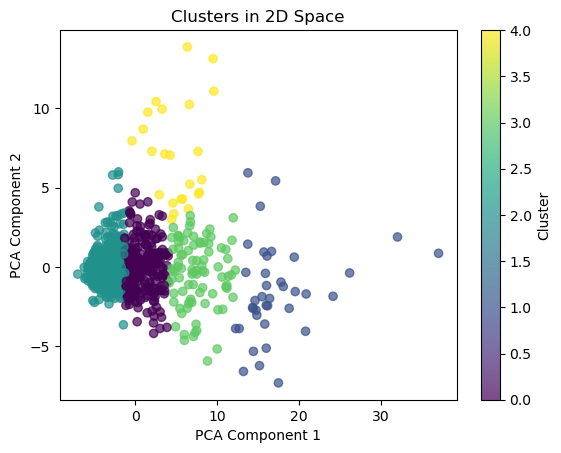

In [20]:
plt.scatter(ms[:, 0], ms[:, 1], c=ms[:, 2], cmap='viridis', alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters in 2D Space")
plt.colorbar(label="Cluster")
plt.show()

# Interpolate surface from clusters

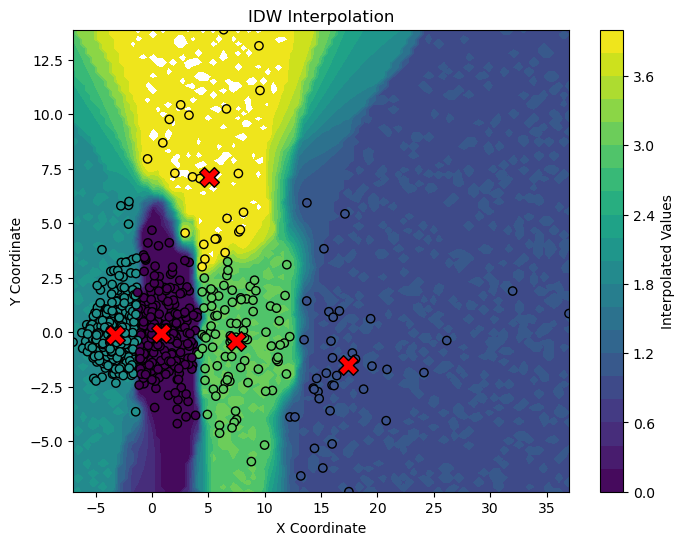

In [21]:
x = ms[:, 0]
y = ms[:, 1]
value = ms[:, 2]

# Create a grid for interpolation
grid_x, grid_y = np.meshgrid(np.linspace(x.min(), x.max(), 100),
                             np.linspace(y.min(), y.max(), 100))

# Inverse Distance Weighting (IDW)
def idw_interpolation(x, y, z, xi, yi, power=2):
    """Performs IDW interpolation."""
    tree = cKDTree(np.c_[x, y])
    distances, idx = tree.query(np.c_[xi.ravel(), yi.ravel()], k=5)  # Find 5 nearest neighbors
    weights = 1 / (distances ** power)  # Compute inverse distance weights
    weights /= weights.sum(axis=1)[:, None]  # Normalize weights
    zi = np.sum(weights * z[idx], axis=1)  # Weighted sum
    return zi.reshape(xi.shape)

# Perform IDW interpolation
grid_z = idw_interpolation(x, y, value, grid_x, grid_y)

# Plot the results
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(grid_x, grid_y, grid_z, cmap='viridis', levels=20)
ax.scatter(x, y, c=value, cmap='viridis', edgecolors='k', marker='o')  # Original points

# Plot centroids
ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', edgecolors='black', label="Centroids")

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('IDW Interpolation')
plt.colorbar(contour, ax=ax, label='Interpolated Values')
plt.show()

# Separate clusters into individual data frames and run ANOVA, and create a data frame with centroids and their values

In [22]:
# Convert to DataFrame and extract cluster sub-dataframes, then run ANOVA on cluster values
df = pd.DataFrame(ms, columns=["x", "y", "value"])
unique_values = sorted(df["value"].unique().tolist())

clusters = {}
for i in unique_values:
    cluster = df.loc[df["value"] == i]
    clusters[i] = cluster

# Convert to DataFrame
df2 = pd.DataFrame(centroids, columns=["x", "y"])

# Add row number column
df2["value"] = df2.index

# Aspatial ANOVA on values

In [23]:
import scipy.stats as stats

# Extract the "value" column from each DataFrame
groups = [df["value"] for df in clusters.values()]

# Perform one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: inf
P-value: 0.0


/Users/erik/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


# Spatial ANOVA on coordinates

In [24]:
# Perform ANOVA for x-coordinates
f_stat_x, p_value_x = stats.f_oneway(
    *[df[df["value"] == v]["x"] for v in df["value"].unique()]
)

# Perform ANOVA for y-coordinates
f_stat_y, p_value_y = stats.f_oneway(
    *[df[df["value"] == v]["y"] for v in df["value"].unique()]
)

print(f"ANOVA X-coordinates: F={f_stat_x}, p={p_value_x}")
print(f"ANOVA Y-coordinates: F={f_stat_y}, p={p_value_y}")

ANOVA X-coordinates: F=1837.6635754312767, p=0.0
ANOVA Y-coordinates: F=136.14885726639343, p=1.118691383628657e-90


# Kernel Density Estimation

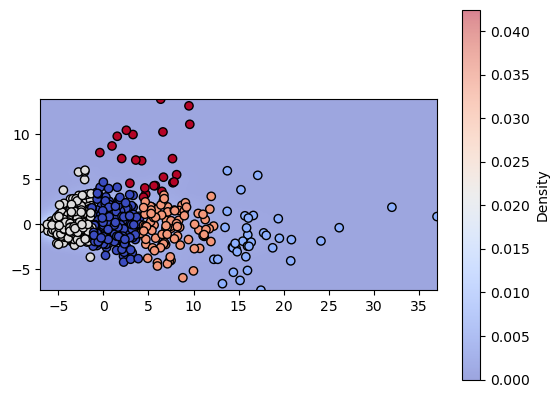

In [25]:
# Compute KDE
kde = stats.gaussian_kde([df["x"], df["y"]])

# Generate grid
x_grid, y_grid = np.meshgrid(np.linspace(df["x"].min(), df["x"].max(), 100),
                             np.linspace(df["y"].min(), df["y"].max(), 100))
density = kde(np.vstack([x_grid.ravel(), y_grid.ravel()]))

# Plot
plt.scatter(df["x"], df["y"], c=df["value"], cmap="coolwarm", edgecolor="k")
plt.imshow(density.reshape(100, 100), origin="lower",
           extent=[df["x"].min(), df["x"].max(), df["y"].min(), df["y"].max()],
           alpha=0.5, cmap="coolwarm")
plt.colorbar(label="Density")
plt.show()

# Voronoi Polygons with space partition

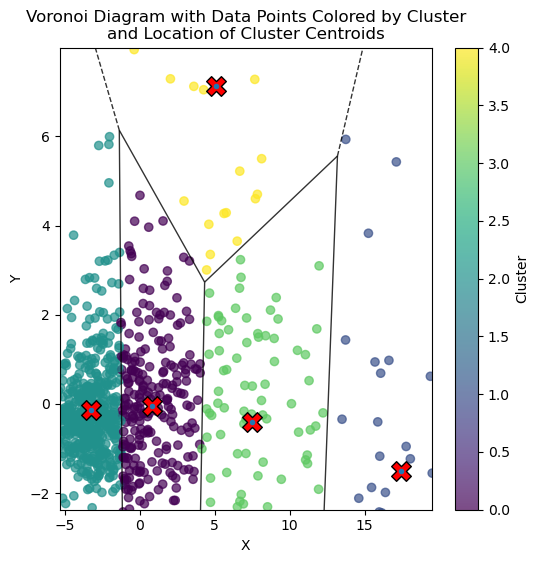

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.spatial import Voronoi, voronoi_plot_2d

# Your DataFrame
df2 = pd.DataFrame({
    "x": [0.819483, 17.417699, -3.286609, 7.499643, 5.101491],
    "y": [-0.040986, -1.510313, -0.138372, -0.398558, 7.124012],
    "value": [0, 1, 2, 3, 4]
})

# Compute Voronoi diagram
points = df2[["x", "y"]].values
vor = Voronoi(points)

# Plot Voronoi diagram with edges only
fig, ax = plt.subplots(figsize=(6, 6))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors="black", line_width=1, line_alpha=0.8)

# Set up colormap for points
cmap = plt.colormaps["viridis"]
norm = mcolors.Normalize(vmin=df2["value"].min(), vmax=df2["value"].max())

plt.scatter(ms[:, 0], ms[:, 1], c=ms[:, 2], cmap='viridis', alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters in 2D Space")
plt.colorbar(label="Cluster")

# Plot centroids
ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', edgecolors='black', label="Centroids")

# Set plot limits and labels
plt.title("Voronoi Diagram with Data Points Colored by Cluster\nand Location of Cluster Centroids")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

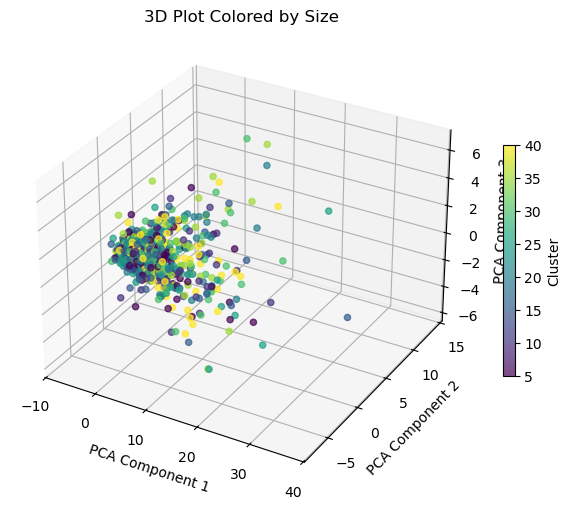

In [21]:
# 3D Plot of clusters colored by size
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

Sz = []
for i in range(892):
    Sz.append(((i%8)*5)+5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Labels and titled
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D Plot Colored by Size")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()